# Credit Risk Modeling & Borrower Segmentation

**End-to-end credit-risk classification on 42,064 borrowers** — synthesizing trade-line and credit-bureau data to assign each borrower to a four-tier risk segment (**P1–P4**) and translate that segment into an underwriting recommendation.

This notebook is a narrated walkthrough that calls the reusable pipeline in `src/`:

| Stage | Module |
|---|---|
| Load + clean + merge | `src/data_prep.py` |
| Chi-Square / VIF / ANOVA selection | `src/feature_selection.py` |
| Encode + train + benchmark | `src/train.py` |
| Tier → recommendation policy | `src/segmentation.py` |
| Score new borrowers | `src/predict.py` |

## Business context

Lenders must decide *who* to approve and *on what terms*. Each borrower is labelled with a **priority tier** derived from repayment behaviour (Days-Past-Due history and account standing):

| Tier | Meaning | Mean credit score |
|---|---|---|
| **P1** | Lowest risk — strongest repayment profile | 716 |
| **P2** | Low-to-moderate risk | 683 |
| **P3** | Elevated risk | 667 |
| **P4** | High risk — weakest profile | 646 |

**Two data sources are combined on `PROSPECTID`:**
- **Trade-line data** (`case_study1`) — the lender's own account-level records: number/age of trade lines, missed payments, secured vs unsecured mix.
- **Bureau (CIBIL) + demographic data** (`case_study2`) — delinquency counts, credit inquiries, income, education, and the `Approved_Flag` target.

The objective: a data-driven baseline that classifies borrowers into P1–P4 and supports scalable approval decisions.

In [1]:
import os, sys, json
import warnings; warnings.filterwarnings('ignore')

# make the project's `src` package importable from the notebooks/ folder
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src import config, segmentation
from src.data_prep import get_clean_data
from src.feature_selection import select_features
from src.train import train
from src.predict import score_borrowers

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load, clean, and merge

Cleaning recipe: drop the missing-value sentinel (`-99999`), remove 8 bureau columns that are mostly missing, drop remaining sentinel rows, then inner-merge trade-line + bureau data. The result is a clean **42,064-borrower** modeling table with zero nulls.

In [2]:
df = get_clean_data()
df.head()

case_study1 (trade-line): (51336, 26)
case_study2 (bureau)    : (51336, 62)
merged analysis dataset : (42064, 79)  | nulls: 0
target distribution:
Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64


,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,...,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,0,0,0.00,0.000,0,0,0,0,1,0,4,1,4,0,72,...,566,0,0,0,Married,12TH,48,M,51000,114,0.200,0.0,0.798,0,1,0.0,0.0,0.000,0.0,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,1,0,1.00,0.000,0,0,0,1,0,0,0,0,1,0,7,...,209,1,0,0,Single,GRADUATE,23,F,19000,50,1.000,0.0,0.370,0,0,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,2,0,0.25,0.000,1,1,0,6,1,0,0,2,6,0,47,...,587,0,0,0,Married,SSC,40,M,18,191,1.000,0.5,0.585,0,0,0.0,0.0,0.000,0.0,1,0,ConsumerLoan,others,693,P2
3,5,3,2,1,0,0,0.000,0.0,0.333,0.667,0,0,0.00,0.000,0,1,0,0,0,0,0,3,0,2,131,...,3951,0,0,0,Married,POST-GRADUATE,48,M,15000,75,0.333,0.0,0.000,0,0,0.0,0.0,0.000,0.0,0,0,AL,AL,753,P1
4,6,6,5,1,0,0,0.000,0.0,0.167,0.833,0,1,0.00,0.167,0,4,0,0,2,0,0,6,0,0,150,...,7,6,5,4,Married,12TH,35,M,0,154,0.167,0.0,0.000,0,0,1.0,0.0,0.429,0.0,1,0,ConsumerLoan,PL,668,P3


### Target distribution

The portfolio is dominated by P2 borrowers (~60%) — a real class imbalance that makes the minority tiers (P1/P4) harder to predict and motivates looking beyond raw accuracy at per-class recall.

In [3]:
ax = (df[config.TARGET].value_counts()[config.TIER_ORDER]
        .plot(kind='bar', color=['#2ca25f','#99d8c9','#fdae6b','#de2d26'], figsize=(6,4)))
ax.set_title('Borrower count by risk tier'); ax.set_xlabel('Risk tier'); ax.set_ylabel('Borrowers')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / 'target_distribution.png', dpi=120); plt.show()

### Risk tiers track creditworthiness

Mean credit score declines monotonically from P1 to P4 — confirming the tiers form a coherent risk ordering rather than arbitrary labels.

In [4]:
score_by_tier = df.groupby(config.TARGET)['Credit_Score'].mean().reindex(config.TIER_ORDER)
ax = score_by_tier.plot(kind='bar', color='#3182bd', figsize=(6,4))
ax.set_title('Mean credit score by risk tier'); ax.set_ylabel('Mean Credit_Score'); ax.set_ylim(600, 740)
for i, v in enumerate(score_by_tier): ax.text(i, v+2, f'{v:.0f}', ha='center')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / 'credit_score_by_tier.png', dpi=120); plt.show()

## 2. Feature selection

Three statistical filters keep only informative, non-redundant indicators:
- **Chi-Square** test of independence for categorical features vs the target.
- **Variance Inflation Factor (VIF ≤ 6)** to drop multicollinear numeric features.
- **One-way ANOVA (p ≤ 0.05)** to keep numeric features that differ across P1–P4.

In [5]:
features = select_features(df)
print(f"\nFinal selected: {len(features['all'])} features "
      f"({len(features['categorical'])} categorical + {len(features['numerical'])} numerical)")

Categorical selection (Chi-Square):
  chi2  MARITALSTATUS      p=3.578e-233  KEEP
  chi2  EDUCATION          p=2.694e-30  KEEP
  chi2  GENDER             p=1.908e-05  KEEP
  chi2  last_prod_enq2     p=0.000e+00  KEEP
  chi2  first_prod_enq2    p=7.850e-287  KEEP
Numerical selection (VIF -> ANOVA):


  VIF<= 6.0: kept 39 / 71 numeric features
  ANOVA p<=0.05: kept 37 / 39 numeric features

Final selected: 42 features (5 categorical + 37 numerical)


## 3. Modeling — benchmark Random Forest vs XGBoost

Features are ordinally encoded (`EDUCATION`), one-hot encoded (other categoricals), and selectively scaled, then split 80/20. We benchmark a Random Forest against a tuned XGBoost classifier. `train()` also writes the model, metrics, and figures to disk.

In [6]:
metrics = train(verbose=False)
pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost (tuned)'],
    'Test accuracy': [metrics['random_forest_accuracy'], metrics['xgboost_accuracy']],
})

,Model,Test accuracy
0,Random Forest,0.7626
1,XGBoost (tuned),0.7800


**XGBoost wins at ~78% accuracy**, the data-driven baseline for this segmentation framework. The full per-class precision/recall report is saved to `reports/classification_report.txt`.

In [7]:
print(config.CLASSIFICATION_REPORT_PATH.read_text())

XGBoost classification report (test set)

              precision    recall  f1-score   support

          P1      0.847     0.762     0.802      1014
          P2      0.816     0.930     0.870      5045
          P3      0.470     0.263     0.337      1325
          P4      0.740     0.727     0.733      1029

    accuracy                          0.780      8413
   macro avg      0.718     0.671     0.686      8413
weighted avg      0.756     0.780     0.761      8413



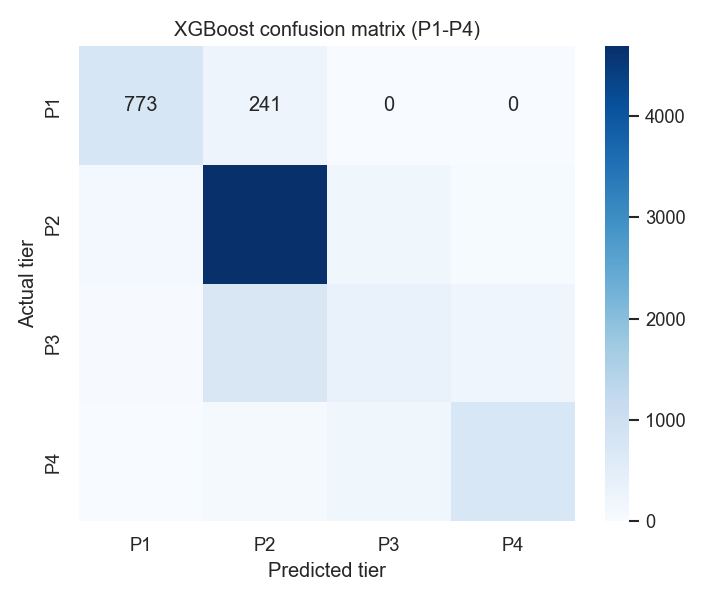

In [8]:
display(Image(filename=str(config.FIGURES_DIR / 'confusion_matrix.png')))

### Primary default-risk drivers

XGBoost feature importance is led by **inquiry behaviour** (`enq_L3m`, `pct_PL_enq_L6m_of_ever`, `time_since_recent_enq`) and **delinquency history** (`max_recent_level_of_deliq`, `num_deliq_6_12mts`, `num_times_60p_dpd`, `Tot_Missed_Pmnt`), with credit-history age and trade-line mix / balance features as secondary signals.

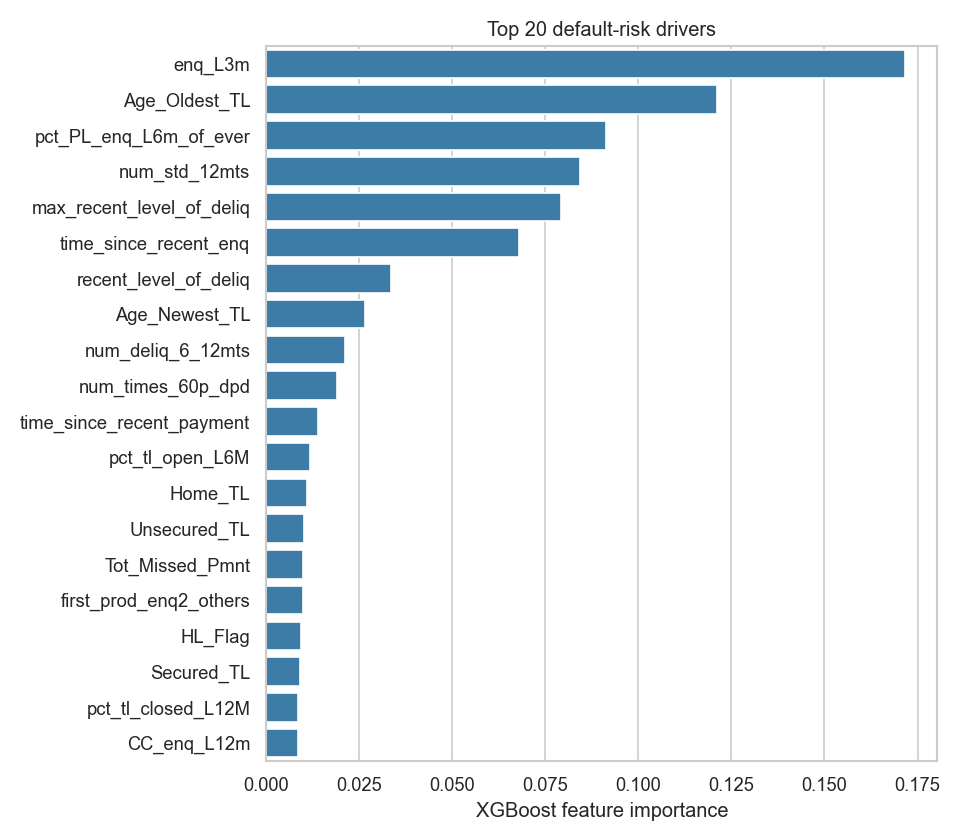

In [9]:
display(Image(filename=str(config.FIGURES_DIR / 'feature_importance.png')))

## 4. Borrower segmentation framework (P1–P4 → underwriting action)

The model's predicted tier maps to a concrete lending decision — the business layer that turns a risk score into an approval recommendation.

In [10]:
pd.DataFrame(segmentation.policy_table()).set_index('tier')

,risk,decision,action
tier,,,
P1,Lowest risk,Auto-approve,Approve with best pricing and highest credit l...
P2,Low-to-moderate risk,Approve,Approve on standard terms; routine verification.
P3,Elevated risk,Manual review,Refer to underwriting; approve only with risk-...
P4,High risk,Decline / escalate,Decline or refer to senior underwriting; appro...


### Scoring example

Reuse the encoding pipeline to score a sample of held-out borrowers end-to-end — each gets a predicted tier and the matching recommendation.

In [11]:
from src.train import build_feature_matrix, scale_features
encoded = scale_features(build_feature_matrix(df, features))
sample = encoded.drop(columns=[config.TARGET]).sample(n=8, random_state=config.RANDOM_STATE)
result = score_borrowers(sample)
result.insert(0, 'actual_tier', df.loc[sample.index, config.TARGET].values)
result[['actual_tier', 'tier', 'decision']]

,actual_tier,tier,decision
38543,P3,P2,Approve
18916,P3,P4,Decline / escalate
37137,P2,P2,Approve
6914,P4,P4,Decline / escalate
19764,P4,P4,Decline / escalate
27290,P2,P2,Approve
19637,P2,P2,Approve
32065,P2,P2,Approve


## Summary

- **42,064 borrowers** assessed by synthesizing trade-line + bureau data across **55+ indicators**.
- Feature selection via **Chi-Square, VIF, and ANOVA**; **XGBoost** benchmarked against Random Forest.
- **~78% accuracy** establishes a scalable, data-driven baseline.
- **Delinquency history and inquiry behaviour** are the dominant default-risk signals.
- A **4-tier (P1–P4) segmentation framework** translates risk into underwriting recommendations.